In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset/raw/students.csv")

df.head()

,Hours_Studied,Tutoring_Sessions,Exam_Score
0,23,0,67
1,19,2,61
2,24,2,74
3,29,1,71
4,19,3,70


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2942 entries, 0 to 2941
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Hours_Studied      2942 non-null   int64
 1   Tutoring_Sessions  2942 non-null   int64
 2   Exam_Score         2942 non-null   int64
dtypes: int64(3)
memory usage: 69.1 KB


Hours_Studied        0
Tutoring_Sessions    0
Exam_Score           0
dtype: int64

In [4]:
df["duration"] = df["Hours_Studied"]

df["sessions_per_day"] = df["Tutoring_Sessions"]

df["productivity_score"] = df["Exam_Score"]

In [5]:
time_labels = ["Morning", "Afternoon", "Night"]

df["time_of_day"] = np.random.choice(
    time_labels,
    size=len(df)
)

df.head()

,Hours_Studied,Tutoring_Sessions,Exam_Score,duration,sessions_per_day,productivity_score,time_of_day,break_time
0,23,0,67,23,0,67,Night,12
1,19,2,61,19,2,61,Morning,17
2,24,2,74,24,2,74,Afternoon,15
3,29,1,71,29,1,71,Afternoon,5
4,19,3,70,19,3,70,Night,27


In [6]:
df["break_time"] = np.random.randint(5, 30, size=len(df))

df.head()

,Hours_Studied,Tutoring_Sessions,Exam_Score,duration,sessions_per_day,productivity_score,time_of_day,break_time
0,23,0,67,23,0,67,Night,17
1,19,2,61,19,2,61,Morning,14
2,24,2,74,24,2,74,Afternoon,29
3,29,1,71,29,1,71,Afternoon,5
4,19,3,70,19,3,70,Night,11


In [7]:
def label_focus(score):

    if score >= 80:
        return "High"

    elif score >= 50:
        return "Medium"

    else:
        return "Low"

df["focus_level"] = df["productivity_score"].apply(label_focus)

df.head()

,Hours_Studied,Tutoring_Sessions,Exam_Score,duration,sessions_per_day,productivity_score,time_of_day,break_time,focus_level
0,23,0,67,23,0,67,Night,17,Medium
1,19,2,61,19,2,61,Morning,14,Medium
2,24,2,74,24,2,74,Afternoon,29,Medium
3,29,1,71,29,1,71,Afternoon,5,Medium
4,19,3,70,19,3,70,Night,11,Medium


In [8]:
df = df[[
    "duration",
    "time_of_day",
    "sessions_per_day",
    "break_time",
    "productivity_score",
    "focus_level"
]]

df.head()

,duration,time_of_day,sessions_per_day,break_time,productivity_score,focus_level
0,23,Night,0,17,67,Medium
1,19,Morning,2,14,61,Medium
2,24,Afternoon,2,29,74,Medium
3,29,Afternoon,1,5,71,Medium
4,19,Night,3,11,70,Medium


In [9]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2888 entries, 0 to 2941
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   duration            2888 non-null   int64 
 1   time_of_day         2888 non-null   object
 2   sessions_per_day    2888 non-null   int64 
 3   break_time          2888 non-null   int32 
 4   productivity_score  2888 non-null   int64 
 5   focus_level         2888 non-null   object
dtypes: int32(1), int64(3), object(2)
memory usage: 146.7+ KB


In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["time_of_day"] = encoder.fit_transform(df["time_of_day"])

df["focus_level"] = encoder.fit_transform(df["focus_level"])

df.head()

,duration,time_of_day,sessions_per_day,break_time,productivity_score,focus_level
0,23,2,0,17,67,1
1,19,1,2,14,61,1
2,24,0,2,29,74,1
3,29,0,1,5,71,1
4,19,2,3,11,70,1


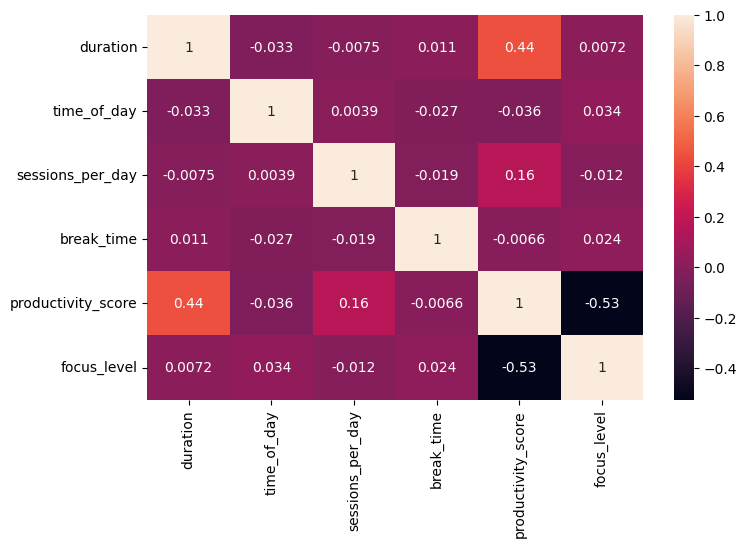

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(df.corr(), annot=True)

plt.show()

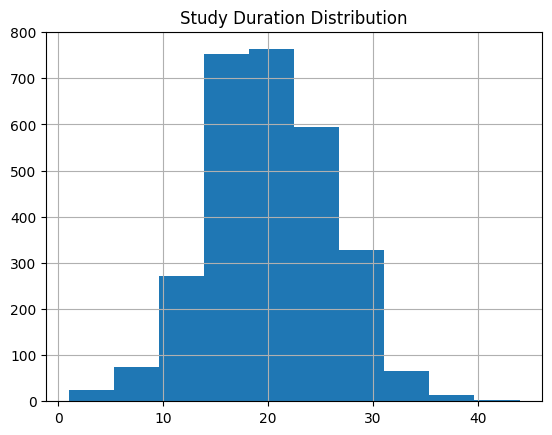

In [12]:
df["duration"].hist()

plt.title("Study Duration Distribution")

plt.show()

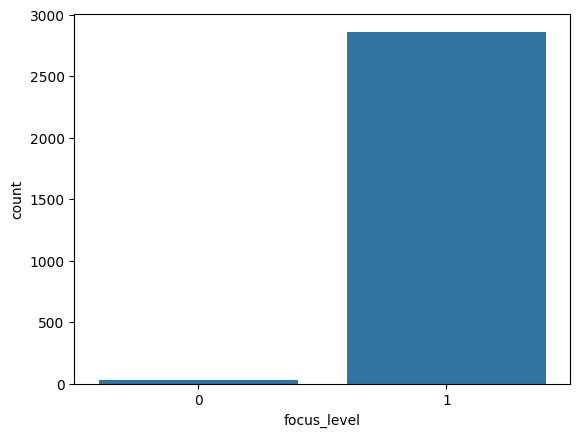

In [13]:
sns.countplot(x="focus_level", data=df)

plt.show()

In [14]:
df.to_csv("../dataset/cleaned/cleaned_data.csv", index=False)